In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/sasa/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /Users/sasa/nltk_data...


True

In [ ]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /Users/sasa/nltk_data...


True

In [ ]:
import pandas as pd
import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import wandb
# wandb.login()

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

/Users/sasa/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_train = train_df
data_test = test_df

In [ ]:
labels_train = data_train['label']
labels_test = data_test['label']

In [ ]:
len(data_train), len(data_test)

(120000, 7600)

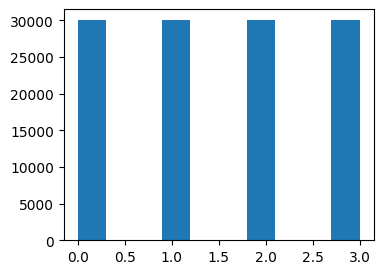

In [ ]:
plt.figure(figsize=(4, 3))
plt.hist(labels_train);

In [ ]:
from wordcloud import WordCloud

def create_cloud_graph(corpus):
    wordcloud = WordCloud(
        width=1600, height=800, max_words=200, background_color='white', collocations=False
    ).generate(' '.join(corpus))
    plt.figure(figsize=(20,10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

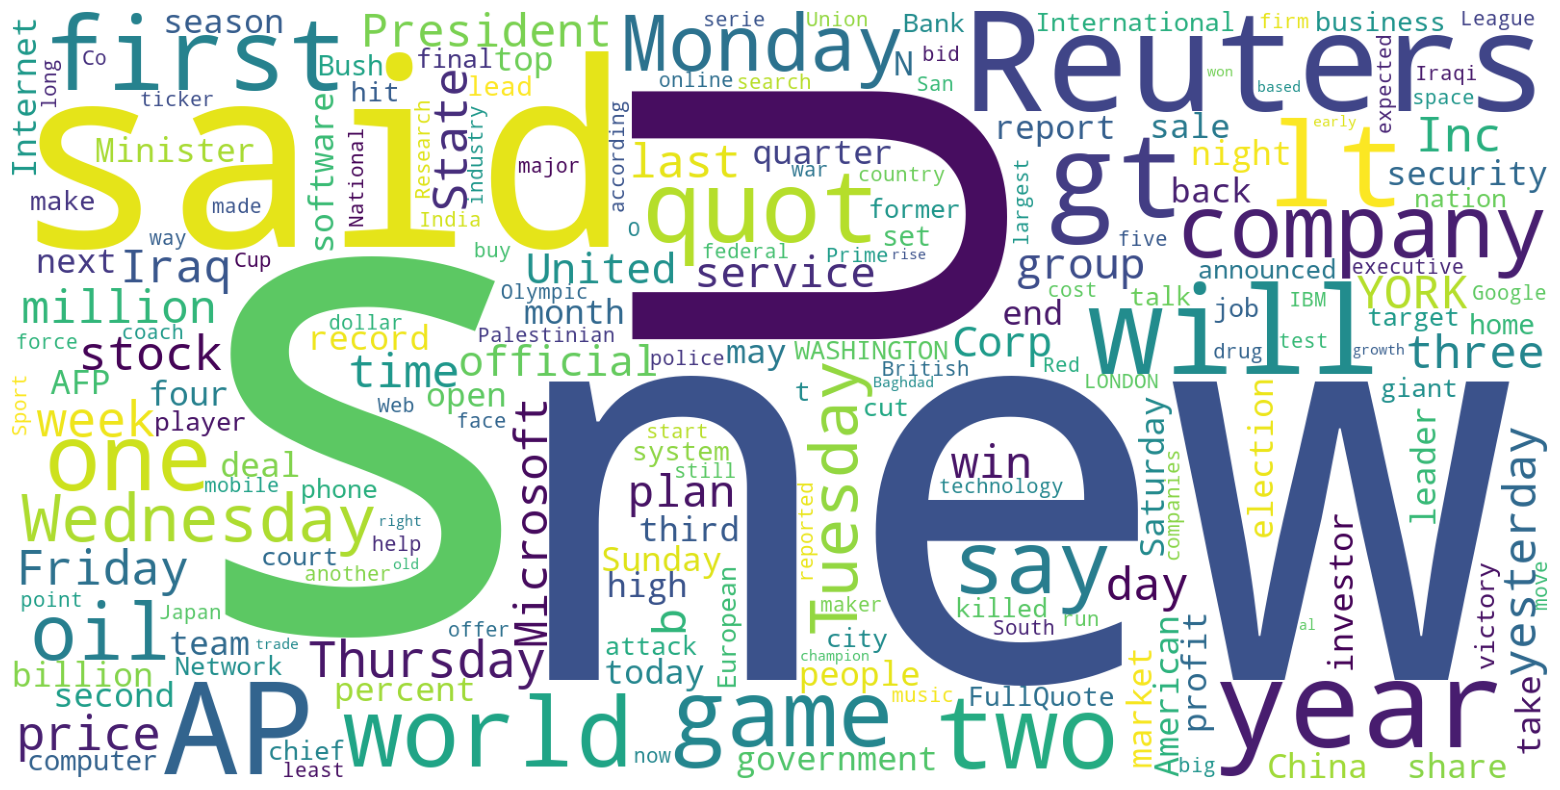

In [ ]:
create_cloud_graph(data_train['text'])

### TF-IDF

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def train_eval_model(train_X, test_X, train_y, test_y):
    model = LogisticRegression(max_iter=500)
    model.fit(train_X, train_y)

    train_pred = model.predict(train_X)
    test_pred = model.predict(test_X)
    train_acc = accuracy_score(train_y, train_pred)
    test_acc = accuracy_score(test_y, test_pred)

    print('Train accuracy:', round(train_acc, 3))
    print('Test accuracy: ', round(test_acc, 3))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=4, max_df=0.95)
tfidf_vectorizer.fit(data_train['text']);

In [ ]:
tfidf_train = tfidf_vectorizer.transform(data_train['text'])
tfidf_test = tfidf_vectorizer.transform(data_test['text'])

In [ ]:
train_eval_model(tfidf_train, tfidf_test, labels_train, labels_test)

Train accuracy: 0.94
Test accuracy:  0.918


In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=10, max_df=0.95, ngram_range=(1, 3))
tfidf_vectorizer.fit(data_train['text']);

In [ ]:
tfidf_train = tfidf_vectorizer.transform(data_train['text'])
tfidf_test = tfidf_vectorizer.transform(data_test['text'])

In [ ]:
train_eval_model(tfidf_train, tfidf_test, labels_train, labels_test)

Train accuracy: 0.951
Test accuracy:  0.92


In [ ]:
import re

def tokenize(text):
    reg = re.compile(r'\w+')
    return reg.findall(text)

In [ ]:
data_tok_train = [tokenize(t.lower()) for t in data_train['text']]
data_tok_test = [tokenize(t.lower()) for t in data_test['text']]

In [ ]:
print(data_tok_train[:2])

[['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again'], ['carlyle', 'looks', 'toward', 'commercial', 'aerospace', 'reuters', 'reuters', 'private', 'investment', 'firm', 'carlyle', 'group', 'which', 'has', 'a', 'reputation', 'for', 'making', 'well', 'timed', 'and', 'occasionally', 'controversial', 'plays', 'in', 'the', 'defense', 'industry', 'has', 'quietly', 'placed', 'its', 'bets', 'on', 'another', 'part', 'of', 'the', 'market']]


In [ ]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
def remove_stopwords(tokenized_texts):
    clear_texts = []
    for words in tokenized_texts:
        clear_texts.append([word for word in words if word not in stop_words])

    return clear_texts

In [ ]:
data_tok_train = remove_stopwords(data_tok_train)
data_tok_test = remove_stopwords(data_tok_test)

In [ ]:
print(data_train['text'][50])
print(data_tok_train[50])

Making Your Insurer Pay If Hurricane Charley blows your house down, how can you make your insurance company pay?
['making', 'insurer', 'pay', 'hurricane', 'charley', 'blows', 'house', 'make', 'insurance', 'company', 'pay']


In [ ]:
from nltk.stem import WordNetLemmatizer

def lemmatize_text(tokenized_texts):
    lemmatized_data = []
    lemmatizer = WordNetLemmatizer()
    for words in tqdm(tokenized_texts):
        lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
        lemmatized_data.append(lemmatized_words)
    return lemmatized_data

In [ ]:
lemmatized_train = lemmatize_text(data_tok_train)
lemmatized_test = lemmatize_text(data_tok_test)

100%|██████████| 7600/7600 [00:00<00:00, 12943.55it/s]


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    lemmatized_train,
    vector_size=100,
    min_count=4,
    window=5
).wv

In [ ]:
w2v_model.get_vector('word')

array([-0.5203559 , -0.6262095 ,  1.3815267 , -1.4971211 ,  0.5438454 ,
        0.3571584 , -0.35587606,  0.7964712 ,  0.39345747, -0.09826887,
       -0.96061516, -0.5234099 , -0.7506415 , -0.12087743, -0.87894297,
       -0.5542663 , -0.11111597, -0.02616058,  1.8760206 , -0.3366314 ,
        0.00831498,  0.03758756,  0.37211272,  0.20572938, -1.1917729 ,
        0.9041717 , -0.2761206 ,  0.53654385,  0.8322971 ,  1.4031249 ,
        0.04534595,  0.29894432,  0.19698383, -0.86066735,  0.68696225,
       -0.8525186 , -0.01415559,  0.70332444, -0.15979311, -0.4990224 ,
        0.82490414,  0.42839095, -0.3890504 , -0.46164203,  1.2175303 ,
       -0.16527718,  0.03534058, -0.02794181, -0.3886191 ,  1.4691408 ,
        0.34788242,  0.31999367,  0.509072  ,  0.3538697 , -0.00756489,
       -0.5186995 , -0.31190372,  0.6490238 , -0.59435403,  0.20688991,
       -1.234846  , -1.3400786 ,  1.5608917 ,  1.0548098 , -0.17104149,
       -0.6861568 ,  0.68239313,  0.08572815, -0.22469953,  0.73

In [ ]:
def encode_dataset(dataset):
    encoded = []
    for words in dataset:
        vectors = [w2v_model.get_vector(word) for word in words if word in w2v_model]
        encoded.append(torch.from_numpy(np.array(vectors)))

    return encoded

In [ ]:
train_embeddings = encode_dataset(lemmatized_train)
test_embeddings = encode_dataset(lemmatized_test)

Text(0, 0.5, 'Count')

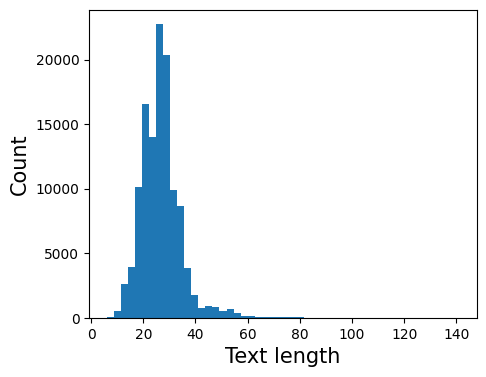

In [ ]:
text_lens = [len(x) for x in train_embeddings]

plt.figure(figsize=(5, 4))
plt.hist(text_lens, bins=50);
plt.xlabel('Text length', size=15)
plt.ylabel('Count', size=15)

In [ ]:
train_dataset = list(zip(train_embeddings, labels_train))
test_dataset = list(zip(test_embeddings, labels_test))

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    x, labels = zip(*batch)
    return pad_sequence(x).permute(1, 0, 2), torch.tensor(labels)

In [ ]:
from torch.utils.data import DataLoader

w2v_train_loader = DataLoader(train_dataset, collate_fn=collate_fn, shuffle=True, batch_size=32)
w2v_test_loader = DataLoader(test_dataset, collate_fn=collate_fn, shuffle=False, batch_size=8)

In [ ]:
batch = next(iter(w2v_test_loader))
batch

(tensor([[[-4.8174e-01, -1.0157e+00, -3.8634e-01,  ...,  6.8391e-01,
            4.8836e-01,  2.7677e+00],
          [ 1.2726e+00, -6.0811e-02, -2.0001e+00,  ...,  6.5508e-01,
            1.3869e+00, -2.5269e+00],
          [-1.6156e+00, -4.1322e-01, -1.8361e+00,  ...,  3.1821e-01,
            1.0802e+00, -6.2898e-01],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],
 
         [[-4.7010e-01,  7.5498e-01,  2.2328e-01,  ..., -2.7791e+00,
           -2.5850e+00,  2.2068e-01],
          [-4.9775e-01,  3.5815e+00, -1.8212e+00,  ..., -2.1051e+00,
           -4.7892e-01, -1.2506e+00],
          [-3.2651e-01,  1.2750e+00, -1.7090e+00,  ..., -2.8581e-01,
           -7.4648e-01,  1.0924e+00],
          ...,
    

## 卷积神经网络

In [ ]:
from torch import nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, hid_dim=100, n_classes=4):
        super().__init__()

        # 卷积层+全连接层+ReLU激活
        self.conv1 = nn.Conv1d(hid_dim, hid_dim, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv1d(hid_dim, hid_dim, kernel_size=3, stride=1, padding=0)

        self.fc = nn.Linear(hid_dim, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: [batch_size, seq_len, dim]

        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = F.max_pool1d(x, x.size(-1)).squeeze(dim=-1)

        x = self.fc(x)
        return x

In [ ]:
def train(model, dataloader, optimizer):

    model.train()
    criterion = nn.CrossEntropyLoss()

    for i, (tokens, labels) in enumerate(dataloader):
        tokens = tokens.to(device)
        labels = labels.to(device)

        logits = model(tokens)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        wandb.log({
            "train_loss": loss.item(),
            "train_accuracy": (logits.argmax(-1) == labels).float().mean().item()
        })


@torch.inference_mode()
def evaluate(model, dataloader):

    model.eval()
    criterion = nn.CrossEntropyLoss()

    correct = []
    losses = []
    for i, (tokens, labels) in enumerate(dataloader):
        tokens = tokens.to(device)
        labels = labels.to(device)

        logits = model(tokens)
        loss = criterion(logits, labels)

        correct.extend((logits.argmax(-1) == labels).float().cpu())
        losses.append(loss.item())

    mean_loss = np.mean(losses)
    accuracy = np.mean(correct)

    wandb.log({
        "test_loss": mean_loss,
        "test_accuracy": accuracy
    })

    return accuracy, mean_loss

In [ ]:
model = SimpleCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

In [ ]:
wandb.init(project="nlp_lesson2", name="simple_cnn")

In [ ]:
for epoch in range(5):
    train(model, w2v_train_loader, optimizer)
    test_accuracy, test_loss = evaluate(model, w2v_test_loader)

wandb.finish()

test_accuracy,▁▄▇██
test_loss,█▅▃▁▁
train_accuracy,▁▆▄▆▄▆▆▆▇▃▃▄▄▆▆▃▆▅▅▃▅▄▅▇▆▇▅▄▆▇▆▅▆▄▆█▄▆▇▅
train_loss,▇▆▅▅▆▅▄▃▃▂▃█▆▄▆▅▅▃▄▃▂▄▁▆▂▅▇▄▄▂▅▂▂▃▅▂▅▃▂▁
test_accuracy,0.89632
test_loss,0.29509
train_accuracy,1
train_loss,0.19992


In [ ]:
print('SimpleCNN')
print('Test accuracy:', test_accuracy)
print('Test loss:', test_loss)

SimpleCNN
Test accuracy: 0.8963158
Test loss: 0.29509065068964113


## TextCNN

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, hid_dim=100, kernel_sizes=[3, 4, 5], n_classes=4):
        super().__init__()

        self.conv = nn.ModuleList([
            nn.Conv1d(in_channels=hid_dim, out_channels=hid_dim, kernel_size=k) for k in kernel_sizes
        ])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(len(kernel_sizes) * hid_dim, n_classes)

    def forward(self, x):
        # x: [batch_size, seq_len, dim]

        x = x.permute(0, 2, 1)

        x = [self.relu(conv(x)) for conv in self.conv]
        x = [F.max_pool1d(c, c.size(-1)).squeeze(dim=-1) for c in x]
        x = torch.cat(x, dim=1)
        x = self.fc(self.dropout(x))
        return x

In [ ]:
model = TextCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

In [ ]:
wandb.init(project="nlp_lesson2", name="textcnn")

In [ ]:
for epoch in range(5):
    train(model, w2v_train_loader, optimizer)
    test_accuracy, test_loss = evaluate(model, w2v_test_loader)

wandb.finish()

test_accuracy,▁▅▆▇█
test_loss,█▅▃▂▁
train_accuracy,▆▂▂▄▅▅▃▁▅▄▂▁▄▅▆█▅▅▅▇▁▅▅▆▆▆▅▆▅▅▅▄▅▅▆█▅▅▅▅
train_loss,█▂▃▂▂▂▁▂▃▅▂▁▂▃▂▂▃▃▂▄▂▃▂▂▂▁▄▁▄▃▄▁▃▃▃▃▂▂▄▁
test_accuracy,0.90184
test_loss,0.28606
train_accuracy,0.8125
train_loss,0.4744


In [ ]:
print('TextCNN')
print('Test accuracy:', test_accuracy)
print('Test loss:', test_loss)

TextCNN
Test accuracy: 0.9018421
Test loss: 0.2860607581840534


In [ ]:
vocabulary = w2v_model.index_to_key

In [ ]:
word2id = {word: i for i, word in enumerate(vocabulary)}
word2id['[PAD]'] = len(word2id)

In [ ]:
def text2ids(texts):
    ids = []
    for words in texts:
        ids.append(torch.tensor([word2id[word] for word in words if word in word2id]))

    return ids

In [ ]:
train_ids = text2ids(lemmatized_train)
test_ids = text2ids(lemmatized_test)
train_dataset = list(zip(train_ids, labels_train))
test_dataset = list(zip(test_ids, labels_test))

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    ids, labels = zip(*batch)
    return (
        pad_sequence(ids, padding_value=word2id['[PAD]']).permute(1, 0),
        torch.tensor(labels)
    )

In [ ]:
from torch.utils.data import DataLoader

ids_train_loader = DataLoader(train_dataset, collate_fn=collate_fn, shuffle=True, batch_size=32)
ids_test_loader = DataLoader(test_dataset, collate_fn=collate_fn, shuffle=False, batch_size=8)

In [ ]:
batch = next(iter(ids_train_loader))[0]

In [ ]:
class EmbeddingTextCNN(TextCNN):
    def __init__(self, vocab_size, hid_dim=100, kernel_sizes=[3, 4, 5], n_classes=4):
        super().__init__(hid_dim, kernel_sizes, n_classes)

        self.embedding = nn.Embedding(vocab_size, hid_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = super().forward(x)
        return x

In [ ]:
model = EmbeddingTextCNN(vocab_size=len(word2id)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-3)

In [ ]:
wandb.init(project="nlp_lesson2", name="textcnn_train_embeddings")

In [ ]:
for epoch in range(10):
    train(model, ids_train_loader, optimizer)
    test_accuracy, test_loss = evaluate(model, ids_test_loader)

wandb.finish()

test_accuracy,▁▃▅▇▇█████
test_loss,█▆▄▂▂▁▁▁▁▁
train_accuracy,▁▃▅▆▇▇▅▆▆▇▇▆▇▇▇▇▇▇█▇▇▇▇▇▇▇▇▇▇█▇▇▇▆▇▇▇▇▇█
train_loss,█▇▄▅▅▅▆▃▃▃▃▄▃▂▂▁▂▂▂▂▃▃▁▂▂▁▂▂▁▂▃▁▂▁▃▂▁▁▁▂
test_accuracy,0.91197
test_loss,0.26794
train_accuracy,1
train_loss,0.12728


In [ ]:
print('TextCNN train embeddings')
print('Test accuracy:', test_accuracy)
print('Test loss:', test_loss)

TextCNN train embeddings
Test accuracy: 0.91197366
Test loss: 0.26793842829175685


In [ ]:
@torch.no_grad()
def explain(model, tokens, label):
    model.eval()
    token_ids = torch.cat(text2ids([tokens])).unsqueeze(0)

    baseline_pred = model(token_ids.to(device)).cpu()
    baseline_prob = torch.softmax(baseline_pred, dim=-1)[0, label]

    drop_one_batch = []
    for t in range(len(token_ids[0])):
        drop_one_token_ids = torch.hstack([token_ids[:, :t], token_ids[:, t+1:]])
        drop_one_batch.append(drop_one_token_ids)

    drop_one_batch = torch.cat(drop_one_batch)

    drop_one_pred = model(drop_one_batch.to(device)).cpu()
    drop_one_prob = torch.softmax(drop_one_pred, dim=-1)[:, label]

    diffs = baseline_prob - drop_one_prob

    return list(zip(tokens, diffs))

In [ ]:
from IPython.display import HTML, display_html


def draw_html(tokens_and_weights, cmap=plt.get_cmap("bwr"), display=True,
              token_template="""<span style="background-color: {color_hex}">{token}</span>""",
              font_style="font-size:14px;"
             ):

    def get_color_hex(weight):
        rgba = cmap(1. / (1 + np.exp(float(weight))), bytes=True)
        return '#%02X%02X%02X' % rgba[:3]

    tokens_html = [
        token_template.format(token=token, color_hex=get_color_hex(weight))
        for token, weight in tokens_and_weights
    ]


    raw_html = """<p style="{}">{}</p>""".format(font_style, ' '.join(tokens_html))
    if display:
        display_html(HTML(raw_html))

    return raw_html


In [ ]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

In [ ]:
i = 0
print(label_names[labels_train[i]])
tokens_and_weights = explain(model, lemmatized_train[i], labels_train[i])
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

Business


wall st bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green

In [ ]:
i = 42
print(label_names[labels_train[i]])
tokens_and_weights = explain(model, lemmatized_train[i], labels_train[i])
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

Business


technology company sue five ex employee marlborough based technology company suing five former employee including three senior manager allegedly conspiring employer working opening competing business

In [ ]:
i = 1000
print(label_names[labels_train[i]])
tokens_and_weights = explain(model, lemmatized_train[i], labels_train[i])
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

Sci/Tech


european union extends microsoft time warner review brussels belgium ap european antitrust regulator said monday extended review deal microsoft corp msft time warner inc

In [ ]:
i = 1023
print(label_names[labels_train[i]])
tokens_and_weights = explain(model, lemmatized_train[i], labels_train[i])
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

Sports


olympics thorpe beat phelps u suffers gold gap athens reuters australian swimmer ian thorpe beat arch rival michael phelps men 200 meter freestyle monday united state trailed china australia japan medal table day three olympic game

In [ ]:
def text (filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        texts = f.read().splitlines()
    return texts

In [ ]:
train_pos = 'data/IMDb/train/positive.txt'
train_nega = 'data/IMDb/train/negative.txt'

In [ ]:
text_pos = text(train_pos)
text_nega = text(train_nega)

train_texts = text_pos + text_nega
train_labels = [1] * len(text_pos) + [0] * len(text_nega)

In [ ]:
test_pos = 'data/IMDb/test/positive.txt'
test_nega = 'data/IMDb/test/negative.txt'

In [ ]:
text1_pos = text(test_pos)
text1_nega = text(test_nega)

test_texts = text1_pos + text1_nega
test_labels = [1] * len(text1_pos) + [0] * len(text1_nega)

In [ ]:
len(train_texts), len(test_texts)

(9825, 9814)

(array([4854.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        4971.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

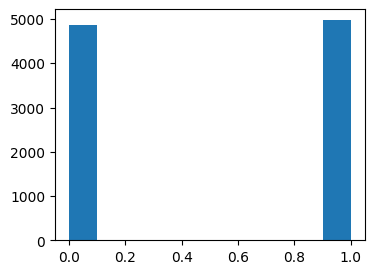

In [ ]:
plt.figure(figsize=(4, 3))
plt.hist(train_labels)

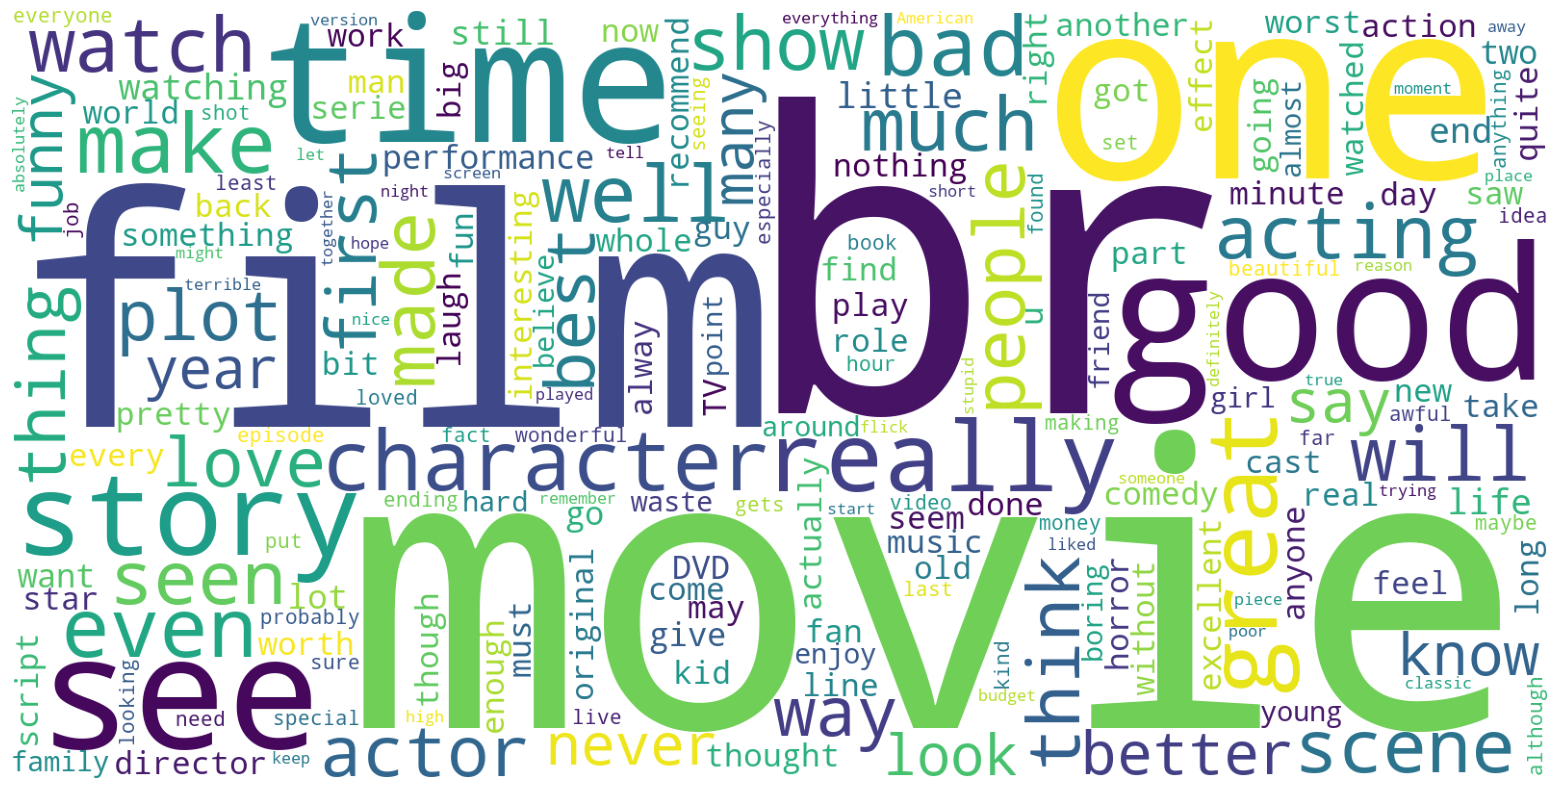

In [ ]:
create_cloud_graph(train_texts)

In [ ]:
#TF-IDF

def train_eval_model(train_X, test_X, train_y, test_y):
    model = LogisticRegression(max_iter=500)
    model.fit(train_X, train_y)

    train_pred = model.predict(train_X)
    test_pred = model.predict(test_X)

    train_acc = accuracy_score(train_y, train_pred)
    test_acc = accuracy_score(test_y, test_pred)

    print('Train accuracy:', round(train_acc, 3))
    print('Test accuracy: ', round(test_acc, 3))

In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=4, max_df=0.95)
tfidf_vectorizer.fit(train_texts)

TfidfVectorizer(max_df=0.95, min_df=4)

In [ ]:
tfidf_train = tfidf_vectorizer.transform(train_texts)
tfidf_test = tfidf_vectorizer.transform(test_texts)

In [ ]:
train_eval_model(tfidf_train, tfidf_test, train_labels, test_labels)

Train accuracy: 0.931
Test accuracy:  0.878


In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=10, max_df=0.95, ngram_range=(1, 3))
tfidf_vectorizer.fit(train_texts)

TfidfVectorizer(max_df=0.95, min_df=10, ngram_range=(1, 3))

In [ ]:
tfidf_train = tfidf_vectorizer.transform(train_texts)
tfidf_test = tfidf_vectorizer.transform(test_texts)

In [ ]:
train_eval_model(tfidf_train, tfidf_test, train_labels, test_labels)

Train accuracy: 0.95
Test accuracy:  0.888
